# Llama-3.2-1B × opc-sft-stage2 leaderboard — cross-model robustness cell (r=64, 9000 steps)

Cross-model cell from `~/.claude/plans/as-part-of-our-tender-quilt.md`. Same opc-sft-stage2 dataset, same horizon, same optimizer arms as Phase L — but base model swapped to Llama-3.2-1B to address the 'does this work on non-OLMo bases' reviewer objection without a full Phase B/C spend.

Cell: Llama-3.2-1B × opc-sft-stage2 (all 4 sub-configs, Llama-tokenized cache `data/opc_sft_stage2_all_packed_seq2048_llama32`) × global_batch=16 (batch=4 × accum=4) × packed_v1.1 × constant LR × α=r × all-linear × bf16 × compile × single-GPU Blackwell. `max_steps=9000`, `eval_every=250`.

- **AdamW**: η ∈ {3e-5, 1e-4, 3e-4}
- **chord-tight k=1** (`adam-polar-product-lora-coupled-spectral-chord-tight`): η ∈ {3e-3, 1e-2, 3e-2}

Source log groups: `{adamw,chord_tight}_robustness_llama32_1b_opc_r64_blackwell` (2 groups).

**Pass criterion** (per plan): Δ direction matches OLMo (tight-chord < AdamW) at any of the 3 LRs. Magnitude can differ; direction cannot. If direction inverts, the result is OLMo-specific and must be reported as such.

**σ anchor**: borrowed `σ_AdamW(packed_v1, opc-sft-stage2, OLMo, r=64) = 0.0017` as a **proxy only** — cross-model σ is not measured.

In [27]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.loader import load_runs
from lora_playground.plotting import compare_variants_figure
from lora_playground.plotting.colors import OPTIM_COLORS, OPTIM_MARKERS

OPT_ADAMW = 'adamw'
OPT_CT    = 'adam-polar-product-lora-coupled-spectral-chord-tight'

def variant_key(cfg):
    opt = cfg.get('optimizer')
    if opt == OPT_ADAMW: return 'AdamW'
    if opt == OPT_CT:    return 'chord-tight k=1'
    return None

VARIANT_COLORS  = {'AdamW': OPTIM_COLORS.get(OPT_ADAMW, 'black'),
                   'chord-tight k=1': OPTIM_COLORS.get(OPT_CT, 'tab:red')}
VARIANT_MARKERS = {'AdamW': OPTIM_MARKERS.get(OPT_ADAMW, 'o'),
                   'chord-tight k=1': OPTIM_MARKERS.get(OPT_CT, 's')}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## r=64

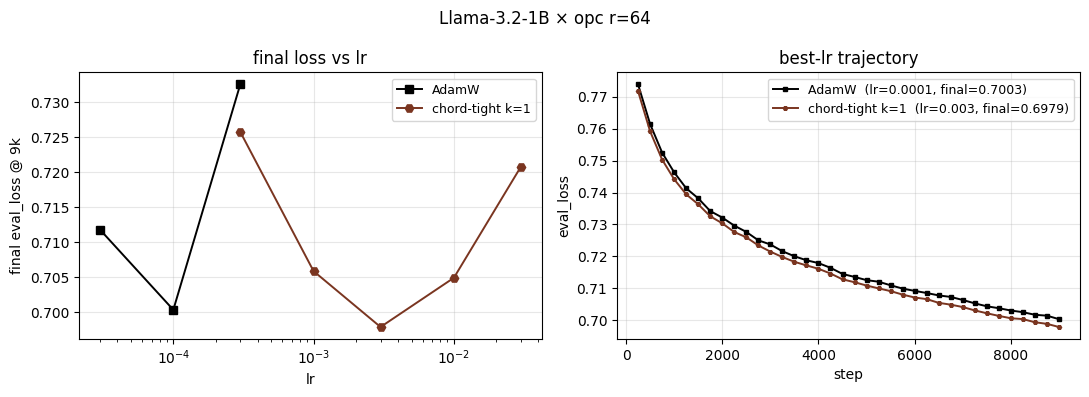

,AdamW,chord-tight k=1
lr,,
0.000030,0.7118,—
0.000100,0.7003,—
0.000300,0.7325,0.7258
0.001000,—,0.7058
0.003000,—,0.6979
0.010000,—,0.7049
0.030000,—,0.7208


,variant,best_lr,final,delta,delta_sigma
0,AdamW,1.0e-04,0.7003,—,—
1,chord-tight k=1,3.0e-03,0.6979,-0.0025,-1.44σ


In [28]:
GROUPS_R64 = [
    'adamw_robustness_llama32_1b_opc_r64_blackwell',
    'chord_tight_robustness_llama32_1b_opc_r64_blackwell',
    'chord_tight_robustness_llama32_1b_opc_r64_extend_left_blackwell',  # chord-tight lr-extension to {3e-4, 1e-3}
]
runs = load_runs(where={'log_group': GROUPS_R64}, logs_root='../logs',
                 warn_cross_commit=False, quiet=True)
dedup = {}
for cfg, hist in runs:
    k = (cfg['optimizer'], float(cfg['lr']))
    if k not in dedup or len(hist) > len(dedup[k][1]):
        dedup[k] = (cfg, hist)
fig, table_df, summary_df = compare_variants_figure(
    variants={'AdamW': {'optimizer': OPT_ADAMW},
              'chord-tight k=1': {'optimizer': OPT_CT}},
    common_where={'lora_r': 64}, ref_label='AdamW', sigma_ref=0.0017,
    max_steps=9000, allow_partial=True,
    prefetched_runs=list(dedup.values()), variant_key=variant_key,
    colors=VARIANT_COLORS, markers=VARIANT_MARKERS,
    suptitle='Llama-3.2-1B × opc r=64', figsize=(11, 4),
)
plt.show()
display(table_df.style.format('{:.4f}', na_rep='—'))
display(summary_df.style.format({
    'best_lr': '{:.1e}', 'final': '{:.4f}',
    'delta': '{:+.4f}', 'delta_sigma': '{:+.2f}σ'
}, na_rep='—'))

## r=256 (rank-extension robustness)

Same two arms, r=256. Source groups: `{adamw,chord_tight}_robustness_llama32_1b_opc_r256_blackwell`.

/mnt/home/nghosh/lora/lora_playground/plotting/figures.py:444: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_lr.legend(fontsize=9)


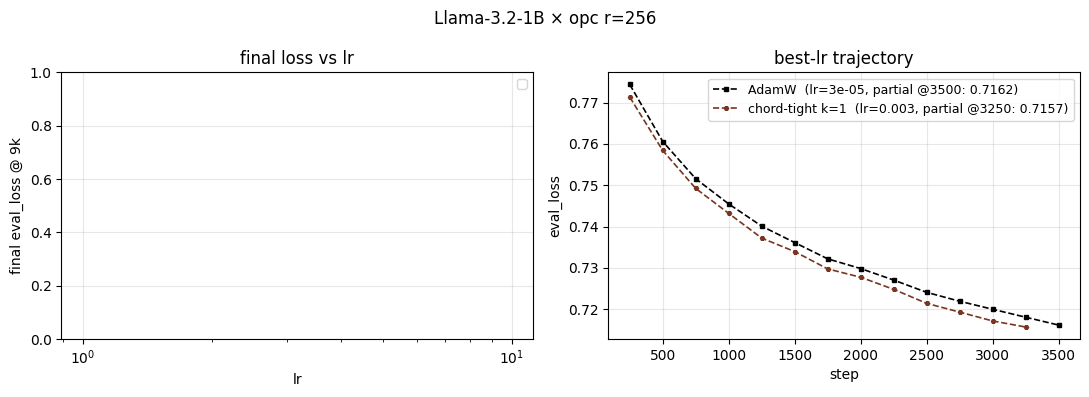

,AdamW,chord-tight k=1
lr,,


In [29]:
GROUPS_R256 = [
    'adamw_robustness_llama32_1b_opc_r256_blackwell',
    'chord_tight_robustness_llama32_1b_opc_r256_blackwell',
]
runs = load_runs(where={'log_group': GROUPS_R256}, logs_root='../logs',
                 warn_cross_commit=False, quiet=True)
dedup = {}
for cfg, hist in runs:
    k = (cfg['optimizer'], float(cfg['lr']))
    if k not in dedup or len(hist) > len(dedup[k][1]):
        dedup[k] = (cfg, hist)
fig, table_df_r256, summary_df_r256 = compare_variants_figure(
    variants={'AdamW': {'optimizer': OPT_ADAMW},
              'chord-tight k=1': {'optimizer': OPT_CT}},
    common_where={'lora_r': 256}, ref_label='AdamW', sigma_ref=0.0017,
    max_steps=9000, allow_partial=True,
    prefetched_runs=list(dedup.values()), variant_key=variant_key,
    colors=VARIANT_COLORS, markers=VARIANT_MARKERS,
    suptitle='Llama-3.2-1B \u00d7 opc r=256', figsize=(11, 4),
)
plt.show()
display(table_df_r256.style.format('{:.4f}', na_rep='\u2014'))
display(summary_df_r256.style.format({
    'best_lr': '{:.1e}', 'final': '{:.4f}',
    'delta': '{:+.4f}', 'delta_sigma': '{:+.2f}\u03c3'
}, na_rep='\u2014'))

## NS-iteration (whitening-fraction) sweep \u2014 does Llama's optimal whitening differ from OLMo's NS-5?

chord-tight with `muon_ns_steps` \u2208 {3, 5, 8} \u2192 whitening fraction \u2248 {0.47, 0.72, 1.0} (measured on the Llama gradient spectrum, stable_rank 10.2). j=5 is the base group. AdamW shown for reference. If a non-5 j beats ns=5, Llama's optimal whitening differs from the OLMo-tuned default.

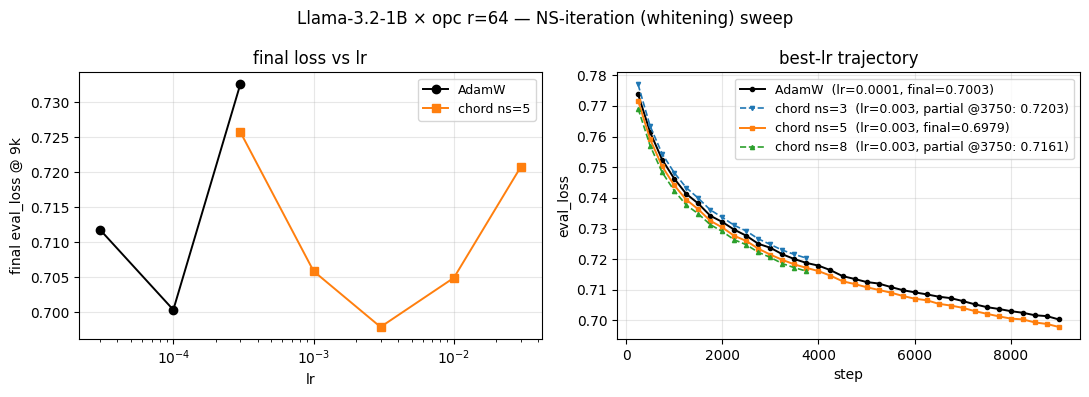

,AdamW,chord ns=3,chord ns=5,chord ns=8
lr,,,,
0.000030,0.7118,—,—,—
0.000100,0.7003,—,—,—
0.000300,0.7325,—,0.7258,—
0.001000,—,—,0.7058,—
0.003000,—,—,0.6979,—
0.010000,—,—,0.7049,—
0.030000,—,—,0.7208,—


,variant,best_lr,final,delta,delta_sigma
0,AdamW,1.0e-04,0.7003,—,—
1,chord ns=5,3.0e-03,0.6979,-0.0025,-1.44σ


In [30]:
GROUPS_NS = [
    'adamw_robustness_llama32_1b_opc_r64_blackwell',
    'chord_tight_robustness_llama32_1b_opc_r64_blackwell',              # ns=5 (base)
    'chord_tight_robustness_llama32_1b_opc_r64_extend_left_blackwell',  # ns=5 (lr extension)
    'chord_tight_robustness_llama32_1b_opc_r64_ns3_blackwell',          # ns=3
    'chord_tight_robustness_llama32_1b_opc_r64_ns8_blackwell',          # ns=8
]
def ns_of(cfg):
    oc = cfg.get('optimizer_config') or {}
    return cfg.get('muon_ns_steps', oc.get('ns_steps'))
def variant_key_ns(cfg):
    opt = cfg.get('optimizer')
    if opt == OPT_ADAMW: return 'AdamW'
    if opt == OPT_CT:
        ns = ns_of(cfg)
        return f'chord ns={ns}' if ns is not None else 'chord ns=?'
    return None
runs = load_runs(where={'log_group': GROUPS_NS}, logs_root='../logs',
                 warn_cross_commit=False, quiet=True)
dedup = {}
for cfg, hist in runs:
    k = (cfg['optimizer'], float(cfg['lr']), ns_of(cfg))
    if k not in dedup or len(hist) > len(dedup[k][1]):
        dedup[k] = (cfg, hist)
NS_COLORS = {'AdamW': OPTIM_COLORS.get(OPT_ADAMW, 'black'),
             'chord ns=3': '#1f77b4', 'chord ns=5': '#ff7f0e', 'chord ns=8': '#2ca02c'}
NS_MARKERS = {'AdamW': 'o', 'chord ns=3': 'v', 'chord ns=5': 's', 'chord ns=8': '^'}
fig, table_df_ns, summary_df_ns = compare_variants_figure(
    variants={'AdamW': {}, 'chord ns=3': {}, 'chord ns=5': {}, 'chord ns=8': {}},
    common_where={'lora_r': 64}, ref_label='AdamW', sigma_ref=0.0017,
    max_steps=9000, allow_partial=True,
    prefetched_runs=list(dedup.values()), variant_key=variant_key_ns,
    colors=NS_COLORS, markers=NS_MARKERS,
    suptitle='Llama-3.2-1B \u00d7 opc r=64 \u2014 NS-iteration (whitening) sweep', figsize=(11, 4),
)
plt.show()
display(table_df_ns.style.format('{:.4f}', na_rep='\u2014'))
display(summary_df_ns.style.format({
    'best_lr': '{:.1e}', 'final': '{:.4f}',
    'delta': '{:+.4f}', 'delta_sigma': '{:+.2f}\u03c3'
}, na_rep='\u2014'))

## Picard ablation \u2014 does the 1/\u03b7 cross-coupling add value on Llama?

chord-tight-CLEAN, polar_method=ns, muon_ns_steps=8 (full whitening). picard=1 collapses to plain polar (cross-coupling term identically zero); picard=2 activates the 1/\u03b7 coupling. If picard=2 beats picard=1 at best-lr, the coupling adds value on Llama (as it did on OLMo packed_v1). AdamW shown for reference.

In [ ]:
OPT_CTC = 'adam-polar-product-lora-coupled-spectral-chord-tight-clean'
GROUPS_PIC = [
    'adamw_robustness_llama32_1b_opc_r64_blackwell',
    'chord_tight_robustness_llama32_1b_opc_r64_ns8_blackwell',                  # non-clean ns=8 = picard=1 ref
    'chord_tight_clean_ns8_picard_ablation_llama32_1b_opc_r64_blackwell',       # clean ns=8 picard=2
]
def pic_of(cfg):
    return cfg.get('_derived', {}).get('effective_picard_iters', cfg.get('picard_iters_override'))
def variant_key_pic(cfg):
    opt = cfg.get('optimizer')
    if opt == OPT_ADAMW: return 'AdamW'
    if opt == OPT_CT:  return 'ns8 picard=1 (ref, non-clean)'   # cross-coupling=0 at picard=1
    if opt == OPT_CTC: return 'clean ns8 picard=2'
    return None
runs = load_runs(where={'log_group': GROUPS_PIC}, logs_root='../logs',
                 warn_cross_commit=False, quiet=True)
dedup = {}
for cfg, hist in runs:
    k = (cfg['optimizer'], float(cfg['lr']), pic_of(cfg))
    if k not in dedup or len(hist) > len(dedup[k][1]):
        dedup[k] = (cfg, hist)
PIC_COLORS = {'AdamW': OPTIM_COLORS.get(OPT_ADAMW, 'black'),
              'ns8 picard=1 (ref, non-clean)': '#1f77b4', 'clean ns8 picard=2': '#d62728'}
PIC_MARKERS = {'AdamW': 'o', 'ns8 picard=1 (ref, non-clean)': 's', 'clean ns8 picard=2': '^'}
fig, table_df_pic, summary_df_pic = compare_variants_figure(
    variants={'AdamW': {}, 'ns8 picard=1 (ref, non-clean)': {}, 'clean ns8 picard=2': {}},
    common_where={'lora_r': 64}, ref_label='AdamW', sigma_ref=0.0017,
    max_steps=9000, allow_partial=True,
    prefetched_runs=list(dedup.values()), variant_key=variant_key_pic,
    colors=PIC_COLORS, markers=PIC_MARKERS,
    suptitle='Llama-3.2-1B \u00d7 opc r=64 \u2014 does picard=2 (1/\u03b7 coupling) beat picard=1?', figsize=(11, 4),
)
plt.show()
display(table_df_pic.style.format('{:.4f}', na_rep='\u2014'))
display(summary_df_pic.style.format({
    'best_lr': '{:.1e}', 'final': '{:.4f}', 'delta': '{:+.4f}', 'delta_sigma': '{:+.2f}\u03c3'
}, na_rep='\u2014'))